# Au verification: multislice vs WPM vs ODE

Thicknes sweep for Au comparing abTEM multislice, WPM, and an adaptive ODE integrator.

In [44]:
%matplotlib widget

import os
import sys
from pathlib import Path

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".4"

import abtem
import diffrax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk
from tqdm import trange
from tqdm.auto import tqdm

# add parent folder (and common src folder) to sys.path so imports can be resolved
parent = Path.cwd().parent
candidates = [parent, parent / "src"]
for p in candidates:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from jax_multislice import (
    electron_refractive_index,
    energy2wavelength,
    wpm_step_adaptive,
    Propagator as convolve2d,
    fresnel_propagation_kernel,
)

abtem.config.set({"device": "cpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)


def beam_amplitude_normalized(psi_xy, h, k, use_fftshift=True):
    Ny, Nx = psi_xy.shape

    # normalized Fourier coefficients so that a unit plane wave has C00 = 1
    C = jnp.fft.fft2(psi_xy) / (Nx * Ny)

    if use_fftshift:
        C = jnp.fft.fftshift(C)
        cy, cx = Ny // 2, Nx // 2
        return jnp.abs(C[cy + k, cx + h])   # [h,k] beam
    else:
        # unshifted indexing: negative orders wrap around
        return jnp.abs(C[k % Ny, h % Nx])

## Crystal and beam setup

In [45]:
atoms = bulk("Au", "fcc", a=4.08, cubic=True)
unitcell_gpts = (128, 128, 128)
energy = 300e3
n_cells_range = range(0, 2)


## Potential generation and probe

Slice thickness: 0.031875
Unit cell thickness: 4.08


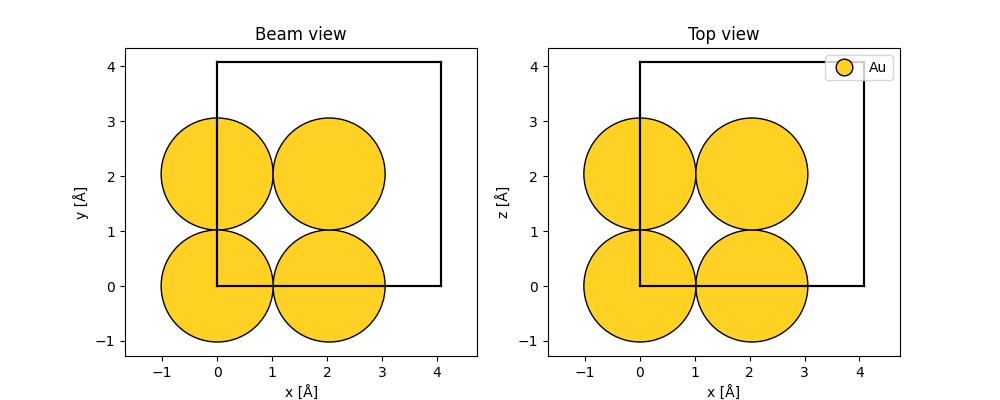

0.019687488897727676 (0.031875, 0.031875)


In [46]:
n_slices = unitcell_gpts[2]  # 128 slices
cell_thickness = atoms.get_cell()[2, 2]
slice_thickness = cell_thickness / n_slices

print(f"Slice thickness: {slice_thickness}")
print(f"Unit cell thickness: {cell_thickness}")
potential = abtem.Potential(
    atoms,
    gpts=unitcell_gpts[:2],
    slice_thickness=4.08 / unitcell_gpts[2],  # 4.08 / 128 to capture one plane per slice
    projection="finite",
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
abtem.show_atoms(atoms, ax=ax1, title="Beam view", merge=False)
abtem.show_atoms(atoms, ax=ax2, plane="xz", title="Top view", legend=True)
plt.show()

wavelength = energy2wavelength(energy)
k0 = 2 * np.pi / wavelength

probe = abtem.PlaneWave(energy=energy)
probe.grid.match(potential)
probe_array = probe.build(lazy=False).array

print(wavelength, probe.sampling)


## WPM helper

In [47]:
def simulate_pattern_wpm(potential, probe, dz, energy, ps):
    wavefront = probe
    for i in trange(potential.shape[0], desc="WPM slices"):
        n = electron_refractive_index(potential[i], energy)
        wavefront, _, _, _ = wpm_step_adaptive(
            wavefront,
            n,
            dz,
            energy,
            ps,
            n_bins=1024,
            power_spacing=2.0,
        )

    diffraction = jnp.abs(jnp.fft.fftshift(jnp.fft.fft2(wavefront)))
    return wavefront, diffraction


def simulate_pattern_fresnel_as(potential, probe, prop_kernel):
    wavefront = probe
    wavefronts = []

    for i in range(potential.shape[0]):
        n = electron_refractive_index(potential[i], energy)
        phase_shift = jnp.exp(1j * 2 * jnp.pi * (n - 1) / wavelength)
        wavefront = wavefront * phase_shift
        wavefront = convolve2d(wavefront, prop_kernel)
        wavefronts.append(wavefront)
    
    exit_wave = wavefront
    
    detector_wavefront = jnp.fft.fftshift(
        jnp.fft.fft2(wavefront)
    )
    diffraction_pattern = (
        jnp.square(detector_wavefront.real)
        + jnp.square(detector_wavefront.imag)
    )
    return exit_wave, diffraction_pattern



## Ground truth ODE helper

In [48]:
def make_G2(ny, nx, ps):
    fy = jnp.fft.fftfreq(ny, d=ps[0])
    fx = jnp.fft.fftfreq(nx, d=ps[1])
    Fy, Fx = jnp.meshgrid(fy, fx, indexing="ij")
    Gy = 2 * jnp.pi * Fy
    Gx = 2 * jnp.pi * Fx
    return (Gx**2 + Gy**2), Gx, Gy


def rhs_helmholtz_diffrax(z, y, args):
    """y = (psi_hat, psi_z_hat). args=(n2_vol, dz, k0, G2)."""
    psi_hat, psi_z_hat = y
    n2_vol, dz, k0, G2 = args
    Nz = n2_vol.shape[0]

    # Linear interpolation of n2 between slices, for adaptive internal z-steps
    t = z / dz
    i = jnp.floor(t).astype(jnp.int32)
    i = jnp.clip(i, 0, Nz - 2)
    frac = t - i.astype(t.dtype)

    n2_i   = jax.lax.dynamic_index_in_dim(n2_vol, i,   axis=0, keepdims=False)
    n2_ip1 = jax.lax.dynamic_index_in_dim(n2_vol, i+1, axis=0, keepdims=False)
    n2_xy = (1.0 - frac) * n2_i + frac * n2_ip1

    psi_xy = jnp.fft.ifft2(psi_hat)
    coupling_hat = jnp.fft.fft2(n2_xy * psi_xy)
    psi_zz_hat = (G2 * psi_hat) - (k0**2) * coupling_hat
    return (psi_z_hat, psi_zz_hat)


@jax.jit
def propagate_diffrax(psi0_xy, n_vol, dz, k0, ps, n_in=1.0, rtol=1e-4, atol=1e-7):
    """Adaptive 'ground truth' integration of the transverse-Fourier Helmholtz ODE.

    Args:
        psi0_xy: input wavefront (Ny, Nx)
        n_vol: refractive index volume (Nz, Ny, Nx)
    """
    Nz, Ny, Nx = n_vol.shape
    G2, _, _ = make_G2(Ny, Nx, ps)

    psi0_hat = jnp.fft.fft2(psi0_xy)

    kz_in = jnp.sqrt(((k0 * n_in)**2 - G2) + 0j)
    psi_z0_hat = 1j * kz_in * psi0_hat
    y0 = (psi0_hat.astype(jnp.complex128), psi_z0_hat.astype(jnp.complex128))

    n2_vol = (n_vol**2).astype(jnp.complex128)

    term = diffrax.ODETerm(rhs_helmholtz_diffrax)
    solver = diffrax.Dopri5()  # adaptive explicit RK (robust; will shrink steps)

    # Let Diffrax pick internal step sizes; start with something reasonable
    dt0 = dz / 10.0

    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=0.0,
        t1=(Nz - 1) * dz,
        dt0=dt0,
        y0=y0,
        args=(n2_vol, dz, k0, G2),
        stepsize_controller=diffrax.PIDController(rtol=rtol, atol=atol),
        saveat=diffrax.SaveAt(t1=True),  # only save the exit plane
        max_steps=1_000_000,             # raise if you hit max_steps
    )

    psi_hat_exit = sol.ys[0]
    psi_exit = jnp.fft.ifft2(psi_hat_exit)

    return psi_exit, psi_hat_exit


# --- Physical Constants (in eV and Angstroms) ---
# hc = 12398.4193 eV⋅Å
HBAR_C = 1973.2698  # hbar * c in eV⋅Å
M_C2   = 510998.95  # Electron rest mass in eV

def rhs_klein_gordon_explicit(z, y, args):
    """
    Explicit Klein-Gordon ODE matching Rother Eq. 11.
    
    Equation:
    [-c^2 h^2 d2/dz2] Psi = [(E - V)^2 - m^2 c^4 + c^2 h^2 G^2] Psi
    
    Rearranged for d2/dz2:
    Psi'' = [ G^2 - ((E - V)^2 - m^2 c^4) / (c hbar)^2 ] Psi
    """
    psi_hat, psi_z_hat = y
    potential_vol, dz, G2, E_total = args
    Nz = potential_vol.shape[0]

    # 1. Linear interpolation of Electrostatic Potential V(r)
    # --------------------------------------------------------
    t = z / dz
    i = jnp.floor(t).astype(jnp.int32)
    i = jnp.clip(i, 0, Nz - 2)
    frac = t - i.astype(t.dtype)

    V_i   = jax.lax.dynamic_index_in_dim(potential_vol, i,   axis=0, keepdims=False)
    V_ip1 = jax.lax.dynamic_index_in_dim(potential_vol, i+1, axis=0, keepdims=False)
    V_xy  = (1.0 - frac) * V_i + frac * V_ip1
    
    # NOTE: Rother's V is potential energy. For electrons, U = -e * phi.
    # If your potential_vol is in Volts (positive at cores), the energy term is (E + |e|V)^2
    # We assume 'V_xy' here is the potential energy term in eV (positive magnitude).
    
    # 2. Calculate Relativistic Terms (Real Space)
    # --------------------------------------------------------
    # This corresponds to the (E - V)^2 - m^2c^4 term in Eq 11.
    # We use (E + V) because electrons gain kinetic energy in the potential.
    kinetic_term_xy = (E_total + V_xy)**2 - M_C2**2
    
    # Normalize by (c*hbar)^2 to match units of G^2 (inverse length squared)
    k_squared_local = kinetic_term_xy / (HBAR_C**2)

    # 3. Compute RHS (Fourier Space mixing)
    # --------------------------------------------------------
    psi_xy = jnp.fft.ifft2(psi_hat)
    
    # Convolve k^2(r) with Psi(r)
    interaction_hat = jnp.fft.fft2(k_squared_local * psi_xy)
    
    # Psi'' = G^2 * Psi - k^2(r) * Psi
    # (G2 is positive, corresponding to -Laplacian in Fourier space)
    psi_zz_hat = (G2 * psi_hat) - interaction_hat
    
    return (psi_z_hat, psi_zz_hat)

def propagate_klein_gordon(psi0_xy, potential_vol, dz, ps, energy_ev, rtol=1e-4, atol=1e-7):
    """
    Propagator using explicit physical constants.
    
    Args:
        energy_ev: Kinetic energy of the beam (e.g. 300e3)
    """
    Nz, Ny, Nx = potential_vol.shape
    G2, _, _ = make_G2(Ny, Nx, ps)

    # Total Energy E = T + mc^2
    E_total = energy_ev + M_C2
    
    # Initial Conditions
    psi0_hat = jnp.fft.fft2(psi0_xy)
    
    # Vacuum wavevector k_in for boundary condition
    # k_vac^2 = (E^2 - m^2c^4) / (hbar*c)^2
    k2_vac = (E_total**2 - M_C2**2) / (HBAR_C**2)
    kz_in = jnp.sqrt(k2_vac - G2 + 0j)
    
    psi_z0_hat = 1j * kz_in * psi0_hat
    y0 = (psi0_hat.astype(jnp.complex128), psi_z0_hat.astype(jnp.complex128))

    # Solver
    term = diffrax.ODETerm(rhs_klein_gordon_explicit)
    solver = diffrax.Dopri5()
    
    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=0.0,
        t1=(Nz - 1) * dz,
        dt0=dz/10.0,
        y0=y0,
        args=(potential_vol, dz, G2, E_total),
        stepsize_controller=diffrax.PIDController(rtol=rtol, atol=atol),
        saveat=diffrax.SaveAt(t1=True),
        max_steps=1_000_000,
    )

    return jnp.fft.ifft2(sol.ys[0]), sol.ys[0]


## Ground truth ODE thickness sweep

In [49]:
potential_single = potential.build(lazy=False).array
n_vol = electron_refractive_index(potential_single, energy)

measurements_ODE_0_0 = []
measurements_ODE_0_28 = []
current_ode_wave = probe_array

for i in tqdm(n_cells_range, desc="ODE cells"):

    if i == 0:
        ode_exit_wave = current_ode_wave
    else:
        ode_exit_wave, _ = propagate_klein_gordon(
            current_ode_wave,
            potential_single,
            slice_thickness,
            probe.sampling,
            energy,
        )
        ode_exit_wave = np.array(ode_exit_wave)[0]

    beam_0_0 = beam_amplitude_normalized(ode_exit_wave, 0, 0, use_fftshift=True)
    beam_0_28 = beam_amplitude_normalized(ode_exit_wave, 0, 28, use_fftshift=True)

    measurements_ODE_0_0.append(beam_0_0)
    measurements_ODE_0_28.append(beam_0_28)

    current_ode_wave = ode_exit_wave

exit_wave_ODE = current_ode_wave


ODE cells:   0%|          | 0/2 [00:00<?, ?it/s]

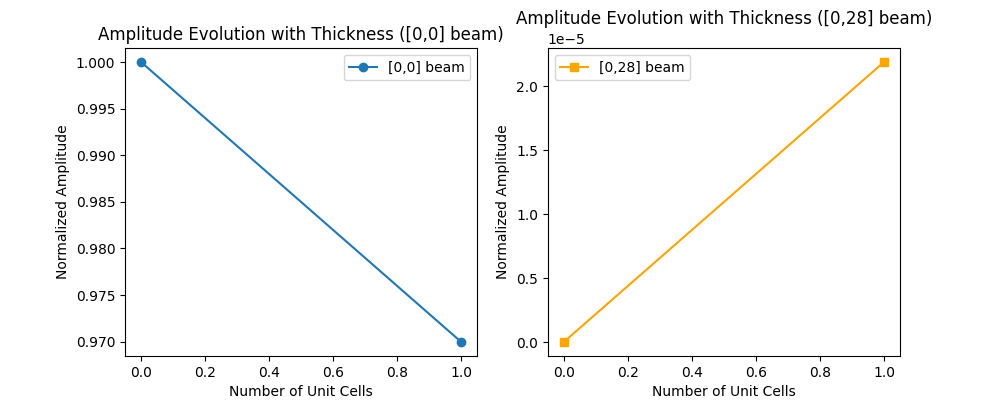

In [50]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(measurements_ODE_0_0, marker="o", label="[0,0] beam")
axs[0].set_xlabel("Number of Unit Cells")
axs[0].set_ylabel("Normalized Amplitude")
axs[0].set_title("Amplitude Evolution with Thickness ([0,0] beam)")
axs[0].legend()
axs[1].plot(measurements_ODE_0_28, marker="s", label="[0,28] beam", color="orange")
axs[1].set_xlabel("Number of Unit Cells")
axs[1].set_ylabel("Normalized Amplitude")
axs[1].set_title("Amplitude Evolution with Thickness ([0,28] beam)")
axs[1].legend()
plt.show()

## Multislice thickness sweep (abTEM)

In [51]:
measurements_multislice = []
probe = abtem.Waves(array=probe_array, sampling=probe.sampling, energy=energy)

# Extract sampling as separate values to ensure proper type handling
sampling_x, sampling_y = probe.grid.sampling[0], probe.grid.sampling[1]

fresnel_propagator = fresnel_propagation_kernel(
    probe.grid.gpts[0],
    probe.grid.gpts[1],
    (sampling_x, sampling_y),  # Pass as tuple explicitly
    z=slice_thickness,
    energy=probe.energy,
)

for i in tqdm(n_cells_range, desc="Multislice cells"):
    if i == 0:
        exit_wave = probe.array
    else: 
        # with abtem.config.set({"antialias.cutoff": 2.0, "antialias.taper": 0.0}):
        #     exit_wave = probe.multislice(
        #         potential,
        #         detectors=abtem.WavesDetector(),
        #     )
        exit_wave, diffraction_pattern = simulate_pattern_fresnel_as(potential_single, probe.array, fresnel_propagator)
        

    exit_ft = np.abs(np.fft.fftshift(np.fft.fft2(exit_wave) / (exit_wave.shape[0] * exit_wave.shape[1])))
    measurements_multislice.append(exit_ft[64, 64 + 0])

    probe = abtem.Waves(array=exit_wave, sampling=probe.sampling, energy=energy)

exit_wave_ms = exit_wave
measurements_multislice = np.array(measurements_multislice)


Multislice cells:   0%|          | 0/2 [00:00<?, ?it/s]

## WPM thickness sweep

In [52]:
measurements_wpm = []
current_wave = probe_array

for i in tqdm(n_cells_range, desc="WPM cells"):
    if i == 0:
        current_wave = probe_array
        diffraction_pattern = jnp.abs(jnp.fft.fftshift(jnp.fft.fft2(current_wave) / (current_wave.shape[0] * current_wave.shape[1])))
    else:
        current_wave, diffraction_pattern = simulate_pattern_wpm(
            potential_single,
            current_wave,
            slice_thickness,
            energy,
        probe.sampling,
    )
    measurements_wpm.append(diffraction_pattern[64, 64 + 0])

exit_wave_wpm = current_wave
measurements_wpm = np.array(measurements_wpm)


WPM cells:   0%|          | 0/2 [00:00<?, ?it/s]

WPM slices: 100%|██████████| 128/128 [00:01<00:00, 101.72it/s]


## Comparison plots

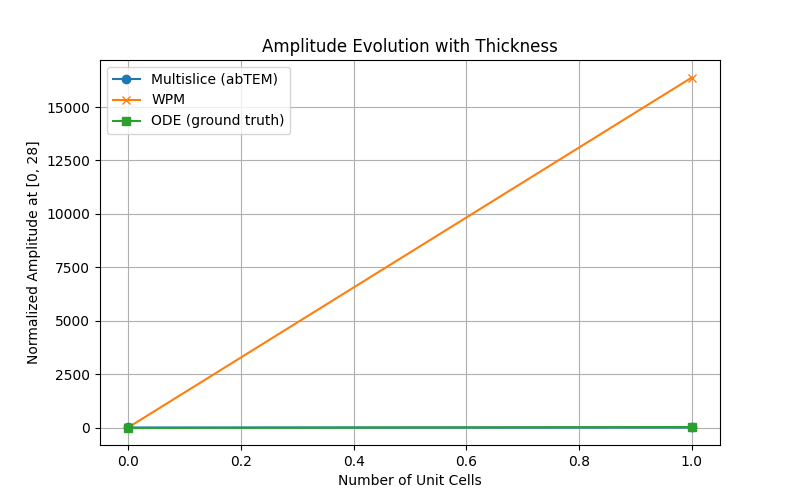

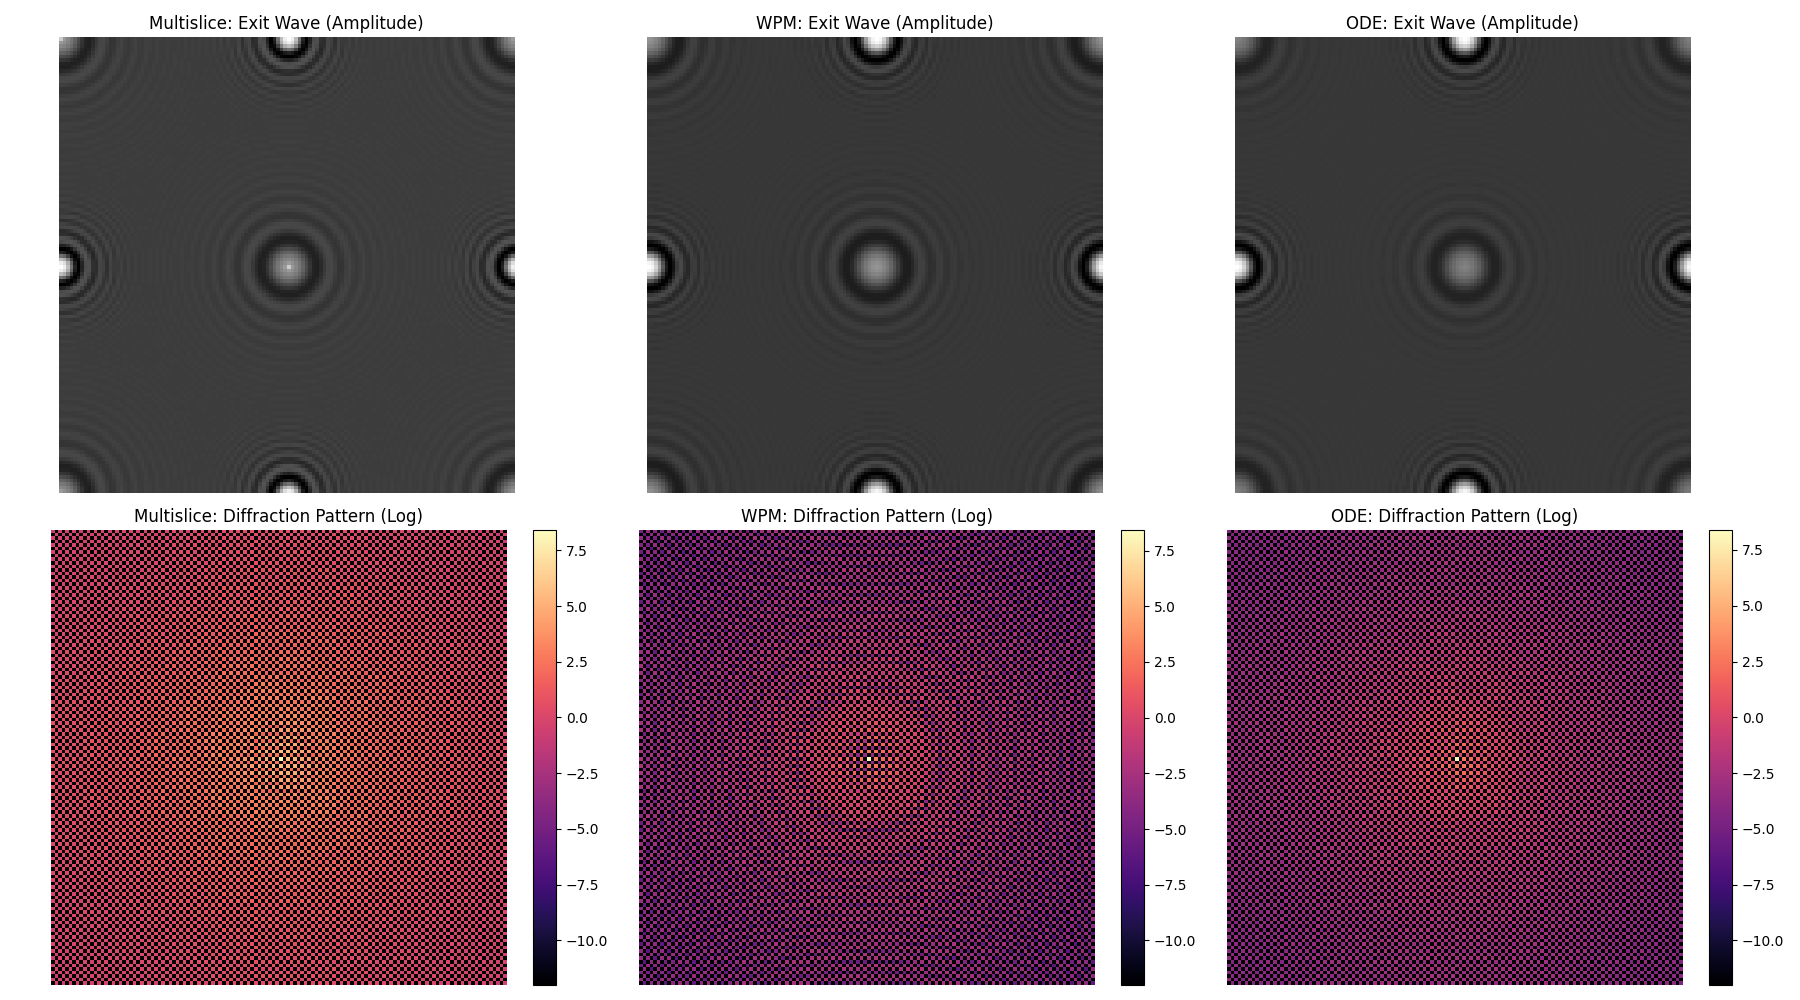

In [53]:
measurements_ODE = np.array(measurements_ODE_0_28)

measurements_ODE_norm = measurements_ODE
measurements_multislice_norm = measurements_multislice
measurements_wpm_norm = measurements_wpm

plt.figure(figsize=(8, 5))
plt.plot(measurements_multislice_norm, marker="o", label="Multislice (abTEM)")
plt.plot(measurements_wpm_norm, marker="x", label="WPM")
plt.plot(measurements_ODE_norm, marker="s", label="ODE (ground truth)")
plt.xlabel("Number of Unit Cells")
plt.ylabel("Normalized Amplitude at [0, 28]")
plt.title("Amplitude Evolution with Thickness")
plt.grid(True)
plt.legend()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Multislice (abTEM) ---
ms_wave = exit_wave_ms
ms_ft = np.fft.fftshift(np.fft.fft2(ms_wave))
ms_log_int = np.log10(np.abs(ms_ft)**2 + 1e-12)

axes[0, 0].imshow(np.abs(ms_wave), cmap="gray")
axes[0, 0].set_title("Multislice: Exit Wave (Amplitude)")
axes[0, 0].axis("off")

im1 = axes[1, 0].imshow(ms_log_int, cmap="magma")
axes[1, 0].set_title("Multislice: Diffraction Pattern (Log)")
axes[1, 0].axis("off")
fig.colorbar(im1, ax=axes[1, 0], fraction=0.046)

# --- WPM ---
wpm_wave = np.array(exit_wave_wpm)
wpm_ft = np.fft.fftshift(np.fft.fft2(wpm_wave))
wpm_log_int = np.log10(np.abs(wpm_ft)**2 + 1e-12)

axes[0, 1].imshow(np.abs(wpm_wave), cmap="gray")
axes[0, 1].set_title("WPM: Exit Wave (Amplitude)")
axes[0, 1].axis("off")

im2 = axes[1, 1].imshow(wpm_log_int, cmap="magma")
axes[1, 1].set_title("WPM: Diffraction Pattern (Log)")
axes[1, 1].axis("off")
fig.colorbar(im2, ax=axes[1, 1], fraction=0.046)

# --- ODE ODE ---
ODE_wave = np.array(exit_wave_ODE)
ODE_ft = np.fft.fftshift(np.fft.fft2(ODE_wave))
ODE_log_int = np.log10(np.abs(ODE_ft)**2 + 1e-12)

axes[0, 2].imshow(np.abs(ODE_wave), cmap="gray")
axes[0, 2].set_title("ODE: Exit Wave (Amplitude)")
axes[0, 2].axis("off")

im3 = axes[1, 2].imshow(ODE_log_int, cmap="magma")
axes[1, 2].set_title("ODE: Diffraction Pattern (Log)")
axes[1, 2].axis("off")
fig.colorbar(im3, ax=axes[1, 2], fraction=0.046)

plt.tight_layout()
plt.show()
